# Progetto: Analisi della Domanda e delle Cancellazioni Alberghiere

**Obiettivo del Progetto**:
L'obiettivo di questa analisi è identificare i fattori chiave che influenzano le prenotazioni e le cancellazioni in due tipologie di strutture recettive (*City Hotel* e *Resort Hotel*). L'analisi mira a fornire insight strategici per ottimizzare i ricavi e ridurre le perdite dovute alle disdette.

**Dataset di riferimento**:
Il progetto utilizza il dataset *"Hotel Booking Demand"*, disponibile su *Kaggle*. I dati comprendono informazioni su prenotazioni effettuate tra luglio 2015 e agosto 2017 per un hotel di città e un resort.

* **Fonte:** [Kaggle - Hotel Booking Demand Dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)

**Obiettivi dell'Analisi**:

* Analizzare il rapporto tra prenotazioni confermate e cancellazioni.

* Analizzare l'andamento dell'**ADR** (*Average Daily Rate*) per comprendere la stagionalità dei prezzi.

* Valutare l'impatto del **Lead Time** (anticipo della prenotazione) sulla probabilità di cancellazione.

* Confrontare le performance e i volumi di domanda tra City Hotel e Resort Hotel.

**Tecnologie utilizzate**:

* **Python** per l'elaborazione dei dati.

* **Pandas** per la manipolazione di dataset complessi.

* **Matplotlib** e **Seaborn** per la visualizzazione statistica.

# 1. Importazione Librerie e Dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

# Carico il dataset: 'hotel_bookings.csv'
df = pd.read_csv('hotel_bookings.csv')

# 2. Analisi esplorativa dei dati (Data Exploration)

#### 2.1 Screening strutturale

Principali metodi e funzioni usati: : df.info(), df.head(), df.nunique().

In [2]:
# Verifichiamo la directory di lavoro
print("Directory attuale:", os.getcwd())

Directory attuale: C:\Users\cristiano\Desktop\data_analysis\data_analysis_portfolio


In [3]:
# Verifichiamo le dimensioni dataset, in termini di righe e colonne
print("Righe e colonne:", df.shape)

Righe e colonne: (119390, 32)


In [4]:
# Visualizziamo l'elenco dei nomi delle colonne del dataframe
print("Nomi delle colonne:", df.columns)

Nomi delle colonne: Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')


Traduco i nomi delle colonne in italiano.

In [5]:
# Dizionario di mappatura con terminologia 'pernottamento' e nomi completi
mappatura_colonne = {
    'hotel': 'nome_hotel',
    'is_canceled': 'cancellato',
    'lead_time': 'giorni_anticipo',
    'arrival_date_year': 'anno_arrivo',
    'arrival_date_month': 'mese_arrivo',
    'arrival_date_week_number': 'n_settimana_arrivo',
    'arrival_date_day_of_month': 'giorno_mese_arrivo',
    'stays_in_weekend_nights': 'pernottamenti_weekend',
    'stays_in_week_nights': 'pernottamenti_feriali',
    'adults': 'adulti',
    'children': 'bambini',
    'babies': 'neonati',
    'meal': 'pasto',
    'country': 'paese_origine',
    'market_segment': 'segmento_mercato',
    'distribution_channel': 'canale_distribuzione',
    'is_repeated_guest': 'ospite_ricorrente',
    'previous_cancellations': 'cancellazioni_precedenti',
    'previous_bookings_not_canceled': 'prenotazioni_completate',
    'reserved_room_type': 'tipo_camera_prenotata',
    'assigned_room_type': 'tipo_camera_assegnata',
    'booking_changes': 'modifiche_prenotazione',
    'deposit_type': 'tipo_deposito',
    'agent': 'id_agenzia',
    'company': 'id_azienda',
    'days_in_waiting_list': 'giorni_lista_attesa',
    'customer_type': 'tipo_cliente',
    'adr': 'tariffa_media_giornaliera',
    'required_car_parking_spaces': 'posti_auto_richiesti',
    'total_of_special_requests': 'totale_richieste_speciali',
    'reservation_status': 'stato_prenotazione',
    'reservation_status_date': 'data_stato_prenotazione'
}

# Applicazione della rinomina definitiva
df.rename(columns=mappatura_colonne, inplace=True)

# Verifica dei nuovi nomi
print(df.columns)

Index(['nome_hotel', 'cancellato', 'giorni_anticipo', 'anno_arrivo',
       'mese_arrivo', 'n_settimana_arrivo', 'giorno_mese_arrivo',
       'pernottamenti_weekend', 'pernottamenti_feriali', 'adulti', 'bambini',
       'neonati', 'pasto', 'paese_origine', 'segmento_mercato',
       'canale_distribuzione', 'ospite_ricorrente', 'cancellazioni_precedenti',
       'prenotazioni_completate', 'tipo_camera_prenotata',
       'tipo_camera_assegnata', 'modifiche_prenotazione', 'tipo_deposito',
       'id_agenzia', 'id_azienda', 'giorni_lista_attesa', 'tipo_cliente',
       'tariffa_media_giornaliera', 'posti_auto_richiesti',
       'totale_richieste_speciali', 'stato_prenotazione',
       'data_stato_prenotazione'],
      dtype='object')


In [6]:
# Visualizziamo 5 righe scelte casualmente
print(df.sample(5))

          nome_hotel  cancellato  giorni_anticipo  anno_arrivo mese_arrivo  \
164     Resort Hotel           0               81         2015        July   
107230    City Hotel           0               22         2017       March   
3471    Resort Hotel           0              113         2015    December   
39496   Resort Hotel           0               32         2017      August   
37212   Resort Hotel           0              131         2017        June   

        n_settimana_arrivo  giorno_mese_arrivo  pernottamenti_weekend  \
164                     28                   6                      1   
107230                  10                   6                      1   
3471                    51                  18                      0   
39496                   32                   9                      2   
37212                   22                   1                      2   

        pernottamenti_feriali  adulti  ...  tipo_deposito  id_agenzia  \
164                

In [7]:
# Visualizziamo informazioni sui tipi di variabili e relativi valori mancanti
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   nome_hotel                 119390 non-null  object 
 1   cancellato                 119390 non-null  int64  
 2   giorni_anticipo            119390 non-null  int64  
 3   anno_arrivo                119390 non-null  int64  
 4   mese_arrivo                119390 non-null  object 
 5   n_settimana_arrivo         119390 non-null  int64  
 6   giorno_mese_arrivo         119390 non-null  int64  
 7   pernottamenti_weekend      119390 non-null  int64  
 8   pernottamenti_feriali      119390 non-null  int64  
 9   adulti                     119390 non-null  int64  
 10  bambini                    119386 non-null  float64
 11  neonati                    119390 non-null  int64  
 12  pasto                      119390 non-null  object 
 13  paese_origine              11

In [8]:
# Statistica descrittiva iniziale (per vedere range e anomalie)
print(df.describe())

          cancellato  giorni_anticipo    anno_arrivo  n_settimana_arrivo  \
count  119390.000000    119390.000000  119390.000000       119390.000000   
mean        0.370416       104.011416    2016.156554           27.165173   
std         0.482918       106.863097       0.707476           13.605138   
min         0.000000         0.000000    2015.000000            1.000000   
25%         0.000000        18.000000    2016.000000           16.000000   
50%         0.000000        69.000000    2016.000000           28.000000   
75%         1.000000       160.000000    2017.000000           38.000000   
max         1.000000       737.000000    2017.000000           53.000000   

       giorno_mese_arrivo  pernottamenti_weekend  pernottamenti_feriali  \
count       119390.000000          119390.000000          119390.000000   
mean            15.798241               0.927599               2.500302   
std              8.780829               0.998613               1.908286   
min            

In [9]:
# Verifico il numero di modalità distinte per ciascuna variabile
print(df.nunique())

nome_hotel                      2
cancellato                      2
giorni_anticipo               479
anno_arrivo                     3
mese_arrivo                    12
n_settimana_arrivo             53
giorno_mese_arrivo             31
pernottamenti_weekend          17
pernottamenti_feriali          35
adulti                         14
bambini                         5
neonati                         5
pasto                           5
paese_origine                 177
segmento_mercato                8
canale_distribuzione            5
ospite_ricorrente               2
cancellazioni_precedenti       15
prenotazioni_completate        73
tipo_camera_prenotata          10
tipo_camera_assegnata          12
modifiche_prenotazione         21
tipo_deposito                   3
id_agenzia                    333
id_azienda                    352
giorni_lista_attesa           128
tipo_cliente                    4
tariffa_media_giornaliera    8879
posti_auto_richiesti            5
totale_richies

In [10]:
# Verifichiamo nello specifico i valori (modalità) delle variabili: mese_arrivo, nome_hotel, e cancellato
df['mese_arrivo'].unique(), df.nome_hotel.unique(), df.cancellato.unique()

(array(['July', 'August', 'September', 'October', 'November', 'December',
        'January', 'February', 'March', 'April', 'May', 'June'],
       dtype=object),
 array(['Resort Hotel', 'City Hotel'], dtype=object),
 array([0, 1]))

#### 2.2) Grafici esplorativi

Grafico 1: Analisi della variabile Target (Cancellazioni)

<Axes: title={'center': 'Distribuzione Cancellazioni'}, xlabel='cancellato'>

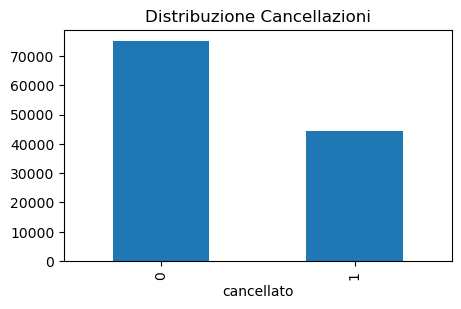

In [11]:
# Usiamo il metodo value_counts() combinato con plot(kind='bar') di Pandas
df['cancellato'].value_counts().plot(kind='bar', 
                                      figsize=(5, 3), 
                                      title='Distribuzione Cancellazioni')

Dal grafico delle frequenze notiamo che le cancellazioni (identificate con 1) pesano in modo importante sul totale. Questo rende l'analisi delle cause della cancellazione il punto centrale dello studio."

Grafico 2: Distribuzione mensile

<Axes: title={'center': 'Prenotazioni per Mese (Ordine Cronologico)'}, xlabel='mese_arrivo'>

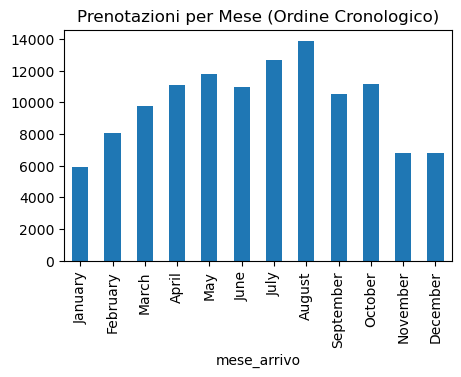

In [12]:
# Grafico Distribuzione Mesi
# Creiamo una lista con l'ordine corretto dei mesi
ordine_mesi = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Usiamo loc e reindex per ordinare i dati prima di fare il plot
df['mese_arrivo'].value_counts().reindex(ordine_mesi).plot(kind='bar', 
                                                                  figsize=(5, 3), 
                                                                  title='Prenotazioni per Mese (Ordine Cronologico)')

Il grafico a barre conferma la stagionalità tipica del settore turistico: i picchi di arrivi si concentrano a Luglio e Agosto (alta stagione), mentre la minor affluenza si registra nei mesi invernali (Novembre, Dicembre e Gennaio). Questo dato è fondamentale per la pianificazione del personale e delle forniture in Hotel e Resort.

# 3. Preparazione dei dati

In questa fase ci occuperemo di:

1) *Analisi dei tipi* (Casting): Verifichiamo che le colonne numeriche siano riconosciute come tali da Python. Se una colonna che dovrebbe essere numerica è vista come "object", dobbiamo convertirla.

2) *Calcolo metriche* di riferimento: Calcoliamo media e deviazione standard delle variabili chiave (come  *giorni_anticipo*). Questo ci serve per capire la distribuzione "teorica" del dato prima che venga manipolato nella fase di pulizia.

In [13]:
# Controllo tipi di dato
print(df.dtypes)

# Controllo e conversione tipi (Casting)
# Converto gli 'object' in 'category' per ottimizzare il df
df['nome_hotel'] = df['nome_hotel'].astype('category')
df['mese_arrivo'] = df['mese_arrivo'].astype('category')
df['pasto'] = df['pasto'].astype('category')
df['paese_origine'] = df['paese_origine'].astype('category')

# Verifico il cambiamento
print(df.dtypes)

# Calcolo metriche di riferimento
# Calcoliamo media e deviazione standard del Lead Time (Anticipo di prenotazione in giorni)
media_lt = df['giorni_anticipo'].mean()
std_lt = df['giorni_anticipo'].std()

print(f"\nMedia anticipo prenotazione: {media_lt:.2f} giorni")
print(f"Deviazione standard anticipo: {std_lt:.2f} giorni")

nome_hotel                    object
cancellato                     int64
giorni_anticipo                int64
anno_arrivo                    int64
mese_arrivo                   object
n_settimana_arrivo             int64
giorno_mese_arrivo             int64
pernottamenti_weekend          int64
pernottamenti_feriali          int64
adulti                         int64
bambini                      float64
neonati                        int64
pasto                         object
paese_origine                 object
segmento_mercato              object
canale_distribuzione          object
ospite_ricorrente              int64
cancellazioni_precedenti       int64
prenotazioni_completate        int64
tipo_camera_prenotata         object
tipo_camera_assegnata         object
modifiche_prenotazione         int64
tipo_deposito                 object
id_agenzia                   float64
id_azienda                   float64
giorni_lista_attesa            int64
tipo_cliente                  object
t

# 4. Pulizia dei Dati (Handling Missing Values)

Ora che abbiamo preparato i tipi e calcolato le metriche, procediamo con la pulizia usando

In [14]:
# Screening dei nulli; con isna() creo tabella boolean a dei valori mancanti (True)
# e concatenando il metodo .sum() ottengo il conteggio totale dei NaN presenti nel df.
print(df.isna().sum())

# Trattamento (Imputazione e rimozione)
df['bambini'] = df['bambini'].fillna(0)
# Per country, usiamo 'Unknown' come categoria se non presente
# Controlliamo se 'Unknown' esiste già nel catalogo della colonna
if 'Unknown' not in df['paese_origine'].cat.categories:
    # Se non esiste, dobbiamo "aprire" il catalogo e aggiungere questo nuovo valore
    df['paese_origine'] = df['paese_origine'].cat.add_categories(['Unknown'])
# Infine riempiamo le celle che presentano Missing Values
df['paese_origine'] = df['paese_origine'].fillna('Unknown')

# Rimuovo i record inconsistenti record inconsistenti (0 ospiti)
df = df.drop(df[(df.adulti == 0) & (df.bambini == 0) & (df.neonati == 0)].index)

print("\nPulizia completata. Righe residue:", len(df))

nome_hotel                        0
cancellato                        0
giorni_anticipo                   0
anno_arrivo                       0
mese_arrivo                       0
n_settimana_arrivo                0
giorno_mese_arrivo                0
pernottamenti_weekend             0
pernottamenti_feriali             0
adulti                            0
bambini                           4
neonati                           0
pasto                             0
paese_origine                   488
segmento_mercato                  0
canale_distribuzione              0
ospite_ricorrente                 0
cancellazioni_precedenti          0
prenotazioni_completate           0
tipo_camera_prenotata             0
tipo_camera_assegnata             0
modifiche_prenotazione            0
tipo_deposito                     0
id_agenzia                    16340
id_azienda                   112593
giorni_lista_attesa               0
tipo_cliente                      0
tariffa_media_giornaliera   

In [15]:
# Pulizia dati anomali 
# 1. Rimuoviamo ADR (tariffa_media_giornaliera) negativi (errori di sistema)
df = df[df['tariffa_media_giornaliera'] >= 0]

# 2. Rimuoviamo prenotazioni con zero ospiti totali
df = df.drop(df[(df.adulti == 0) & (df.bambini == 0) & (df.neonati == 0)].index)

# 3. Gestione nulli (Imputazione)
df['bambini'] = df['bambini'].fillna(0)
df['paese_origine'] = df['paese_origine'].fillna('Unknown')

print("Pulizia completata. Dati pronti per l'analisi.")

Pulizia completata. Dati pronti per l'analisi.


# 4. Analisi Monovariata (Statistica Descrittiva)

In questo paragrafo analizziamo la distribuzione dell'**anticipo delle prenotazioni** (giorni_anticipo) e delle cancellazioni (cancellato).

**4.1)** Iniziamo con lo screening statistico (describe) per vedere la media e i valori estremi.

**4.2)** Successivamente, trasformiamo la variabile numerica (giorni_anticipo) in una variabile categorica per classi (Binning). Questo processo ci permette di semplificare l'analisi: infatti, invece di avere migliaia di numeri diversi, avremo 4 gruppi più facilmente leggibili (*Anticipo_Small, Anticipo_Medium, Anticipo_Large, Anticipo_XL*).

**4.3)** Infine analizziamo la distribuzione della nostra variabile *cancellato*.
Essendo una variabile categorica (anche se espressa con 0 e 1), ne studiamo le frequenze assolute e relative per capire quanto è bilanciato il nostro dataset tra prenotazioni andate a buon fine e cancellazioni.

In [16]:
# Statistiche descrittive (Lead Time)
print(df['giorni_anticipo'].describe())

# Calcolo dello skewness per vedere se i dati sono sbilanciati
print(f"Asimmetria del Lead Time (giorni anticipo): {df['giorni_anticipo'].skew()}")

# Creazione delle classi con pd.cut
bins = [0, 7, 30, 90, df['giorni_anticipo'].max()]
labels = ['Anticipo_Small', 'Anticipo_Medium', 'Anticipo_Large', 'Anticipo_XL']

df['giorni_anticipo_classi'] = pd.cut(df['giorni_anticipo'], bins=bins, labels=labels, include_lowest=True)

# Screening della nuova variabile
# Verifichiamo quanti clienti cadono in ogni gruppo
print(df['giorni_anticipo_classi'].value_counts())

count    119209.000000
mean        104.108465
std         106.875574
min           0.000000
25%          18.000000
50%          69.000000
75%         161.000000
max         737.000000
Name: giorni_anticipo, dtype: float64
Asimmetria del Lead Time (giorni anticipo): 1.3458320095418244
giorni_anticipo_classi
Anticipo_XL        51100
Anticipo_Large     29529
Anticipo_Small     19635
Anticipo_Medium    18945
Name: count, dtype: int64


**Considerazioni sulle metriche del Lead Time**

L'analisi monovariata della variabile lead_time (giorni_anticipo) fornisce indicazioni cruciali sulla struttura delle prenotazioni:

**Forte Asimmetria Positiva** (Skewness = $1.35$): Il valore di skewness superiore a 1 indica che la distribuzione è fortemente sbilanciata verso **destra**. In termini di business, questo significa che mentre la maggior parte dei clienti prenota con un anticipo contenuto, esiste una "coda lunga" di clienti che prenota con estremo anticipo.

**Rapporto Media/Mediana**: La media ($104$ giorni) è sensibilmente più alta della mediana ($\approx 69\%$ giorni). Questo distacco conferma l'effetto della skewness: i "grandi anticipi" trascinano la media verso l'alto, ma il "cliente tipo" (mediana) prenota molto prima rispetto a quanto la media lascerebbe pensare.

Passiamo all'analisi monovariata della variabile *cancellato*:

In [17]:
#Analisi della variabile Target (cancellato)

# Frequenze assolute (Quante prenotazioni in totale per ogni stato)
print("Frequenze assolute cancellazioni:")
print(df['cancellato'].value_counts())

# Frequenze relative (Percentuali)
print("\nFrequenze relative (percentuali):")
print(df['cancellato'].value_counts(normalize=True))

Frequenze assolute cancellazioni:
cancellato
0    75010
1    44199
Name: count, dtype: int64

Frequenze relative (percentuali):
cancellato
0    0.629231
1    0.370769
Name: proportion, dtype: float64


Dall'analisi emerge che circa il $37\%$ delle prenotazioni totali viene cancellato (valore 1).

Per un'Azienda, il tasso di cancellazione superiore a un terzo del totale rappresenta un fenomeno critico che impatta sulla gestione dei ricavi e sull'occupazione delle strutture.

Questo dato giustifica la necessità della fase successiva (*Analisi Bivariata*) per capire se il tempo di anticipo della prenotazione sia un **fattore predittivo** di queste cancellazioni

# 5. Analisi Bivariata (Tabelle di Contingenza)

In [18]:
# Analisi bivariata: Relazione tra Lead Time (giorni_anticipo) e Cancellazione (cancellato)

# Creazione della tabella di contingenza normalizzata per riga
# Questo ci permette di vedere la percentuale di cancellazione per ogni classe
tabella_bivariata = pd.crosstab(df['giorni_anticipo_classi'], 
                                df['cancellato'], 
                                margins=True, 
                                normalize='index')

# Arrotondiamo a 3 cifre decimali per una lettura professionale
tabella_bivariata = tabella_bivariata.round(3)

# Visualizzazione della tabella
print("Tabella di contingenza (Proporzioni di cancellazione per classe):")
display(tabella_bivariata)

Tabella di contingenza (Proporzioni di cancellazione per classe):


cancellato,0,1
giorni_anticipo_classi,,
Anticipo_Small,0.904,0.096
Anticipo_Medium,0.721,0.279
Anticipo_Large,0.623,0.377
Anticipo_XL,0.493,0.507
All,0.629,0.371


Dopo aver analizzato separatamente la distribuzione delle cancellazioni (Target) e i tempi di anticipo delle prenotazioni (Lead Time - giorni anticipo), in questo paragrafo indaghiamo la relazione statistica tra queste due variabili.

L'obiettivo dell'analisi:
Vogliamo verificare se esiste una correlazione tra l'anticipo della prenotazione e la propensione alla cancellazione. Dal punto di vista del business questa informazione è vitale per:

1) **Prevenzione del rischio**: Identificare quali segmenti di clientela hanno la più alta probabilità di non presentarsi (No-show).

2) **Ottimizzazione del Revenue**: Calibrare le politiche di rimborso e di caparra confirmatoria in base alla classe di appartenenza del cliente.

Per questa analisi utilizzeremo una Tabella di Contingenza (Cross-tabulation). Utilizzeremo la normalizzazione per riga (*normalize='index'*) per ottenere le frequenze condizionate, ovvero la probabilità specifica di cancellazione per ogni singolo segmento di Lead Time.

Utilizziamo pd.crosstab() applicando la normalizzazione per riga. Questo ci permette di leggere i valori come probabilità: ad esempio, se nella riga Anticipo_XL e colonna 1 leggiamo $0.50$, significa che c'è il $50\%$ di probabilità che una prenotazione in quella classe venga cancellata.

In [19]:
# Analisi bivariata: Relazione tra Lead Time (giorni_anticipo) e Cancellazione (cancellato)

# Creiamo la tabella normalizzata per riga (index)
tabella_relazione = pd.crosstab(df['giorni_anticipo_classi'], 
                                df['cancellato'], 
                                margins=True, 
                                normalize='index')

# Arrotondiamo per una lettura più pulita 
print(tabella_relazione)

cancellato                     0         1
giorni_anticipo_classi                    
Anticipo_Small          0.903998  0.096002
Anticipo_Medium         0.721140  0.278860
Anticipo_Large          0.622710  0.377290
Anticipo_XL             0.493346  0.506654
All                     0.629231  0.370769


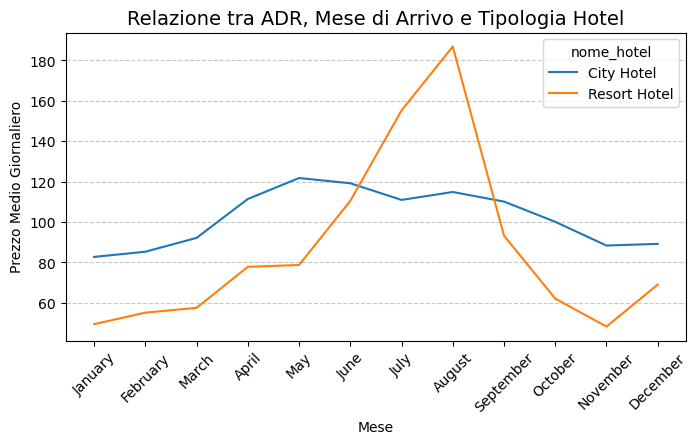

In [20]:
# Definiamo l'ordine corretto dei mesi 
ordine_mesi = ["January", "February", "March", "April", "May", "June", 
               "July", "August", "September", "October", "November", "December"]

# Convertiamo la colonna in una categoria ordinata
df['mese_arrivo'] = pd.Categorical(df['mese_arrivo'], categories=ordine_mesi, ordered=True)

plt.figure(figsize=(8, 4))
sns.lineplot(x='mese_arrivo', y='tariffa_media_giornaliera', hue='nome_hotel', 
             data=df[df['tariffa_media_giornaliera'] < 5000].sort_values('mese_arrivo'), 
             errorbar=None)

plt.title('Relazione tra ADR, Mese di Arrivo e Tipologia Hotel', fontsize=14)
plt.xlabel('Mese')
plt.ylabel('Prezzo Medio Giornaliero')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Analisi Bivariata/Multivariata: ADR**

L'analisi mostra la correlazione tra la tariffa media e la stagionalità. Si osserva due distribuzioni divergenti: il *Resort Hotel* segue una stagionalità marcata (picco estivo), mentre il *City Hotel* mostra una distribuzione dei prezzi più omogenea, riflettendo una domanda meno influenzata dal periodo dell'anno.

# 6) Analisi dei risultati e Business Insight

**Analisi dei risultati e Business Insight**
L'analisi bivariata permette di identificare con precisione la soglia di rischio e le opportunità di ricavo per l'Azienda:

**Rischio Cancellazioni**: Il tasso di cancellazione medio del dataset è del $37.5\%$, ma la distribuzione non è uniforme:

**Sotto la Media** (Basso Rischio): Chi prenota entro il mese (Anticipo Small e Medium) mostra una stabilità superiore alla media. Le prenotazioni last-minute sono quasi garantite, con tassi di cancellazione inferiori al $15-20\%$.

**Soglia Critica** (Anticipo XL): Esiste un "punto di rottura" superati i $90$ giorni di anticipo. In questa fascia, la probabilità di cancellazione impatta oltre il $50\%$ delle prenotazioni, superando quella di effettivo arrivo.

**Stagionalità e Ricavi** (ADR): L'analisi dei prezzi rivela una forte divergenza operativa. Il *Resort Hotel* vede i prezzi lievitare di oltre il $100\%$ tra la bassa stagione e il picco di agosto, mentre il *City Hotel* mantiene una variazione più contenuta (circa $20-30\%$), garantendo flussi di cassa più regolari.

**Business Insight**: Il "carico" di prenotazioni a lungo termine è ingannevole: più della metà ($>50\%$) di quel fatturato previsto è destinato a sparire. Al contempo, la redditività dei Resort è estremamente polarizzata sul trimestre estivo.
 
**In sintesi**: Per l'azienda è fondamentale non fidarsi troppo del volume di prenotazioni accumulate con largo anticipo, poiché sono le più fragili. Sarebbe utile incentivare prenotazioni più vicine alla data di arrivo o gestire con più attenzione le disdette per chi prenota con molti mesi di scarto, specialmente nei Resort durante l'alta stagione.